In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import matplotlib
matplotlib.rcParams.update({'font.size': 10, 'text.usetex': True, 'font.family': 'serif', 'font.serif': ['Computer Modern'], 'figure.figsize': (10,10)})
from mpire import WorkerPool

from koala import plotting as pl
from koala import graph_utils as gu
from koala.pointsets import uniform
from koala.graph_color import edge_color
from koala.voronization import generate_lattice

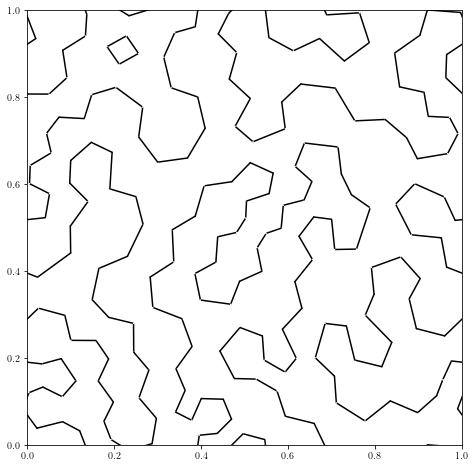

In [2]:
points = uniform(100)
lattice = generate_lattice(points)
lattice = gu.lloyd_relaxation(lattice, 10)

coloring = edge_color(lattice)
coloring = coloring[1]
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect("equal")
pl.plot_edges(lattice, ax=ax, labels = coloring, color_scheme=['w','k','k'])

plt.savefig("amorphous_colouring.pdf")

44
1974


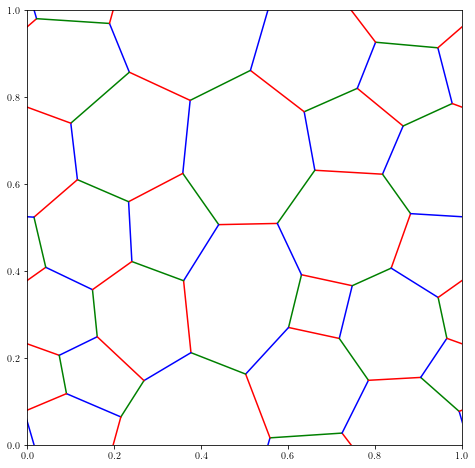

In [3]:
points = uniform(22)
lattice = generate_lattice(points)
lattice = gu.lloyd_relaxation(lattice, 10)

print(lattice.n_vertices)

coloring = edge_color(lattice,all_solutions=True)
c = coloring[1][0]
print(coloring[1].shape[0])
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect("equal")
pl.plot_edges(lattice, ax=ax, labels = c, color_scheme=['r','g','b'])

# plt.savefig("amorphous_colouring.pdf")

In [18]:
n_repeats = 50

n_range = np.arange(4,30)

output = np.zeros((len(n_range),6))
def f(n):
    num_out = []
    n_sites = n*2
    for x in range(n_repeats):
        points = uniform(n)
        lattice = generate_lattice(points,shift_vertices=False)
        coloring = edge_color(lattice,all_solutions=True)
        n_colourings = coloring[1].shape[0]
        num_out.append(n_colourings)
    
    min, max = np.min(num_out), np.max(num_out)
    upper_lower_quartile = np.percentile(num_out, [25, 75])
    avg_num = np.mean(num_out)

    return (n_sites, min, max, upper_lower_quartile[0], upper_lower_quartile[1], avg_num)

with WorkerPool(n_jobs=8) as pool:
    result = pool.map(f, list(n_range), progress_bar=True)


  0%|          | 0/26 [00:00<?, ?it/s]

In [23]:

n_sites = np.array([x[0] for x in result])
mins = np.array([x[1] for x in result])
maxs = np.array([x[2] for x in result])
lower_quartile = np.array([x[3] for x in result])
upper_quartile = np.array([x[4] for x in result])
avg_num = np.array([x[5] for x in result])

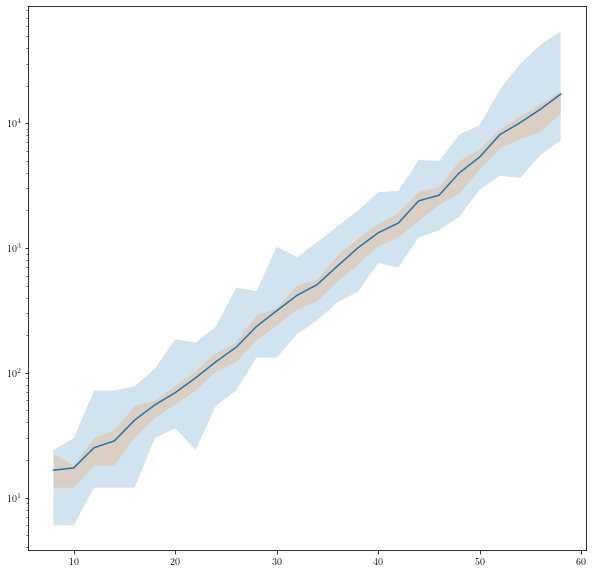

In [24]:
plt.plot(n_sites, avg_num)
plt.fill_between(n_sites, mins, maxs, alpha=0.2)
plt.fill_between(n_sites, lower_quartile, upper_quartile, alpha=0.2)

# plt.plot(output[:,0], func(output[:,0]))

plt.yscale('log')

In [29]:
# fit straight line with polyfit

from scipy.optimize import curve_fit

means = np.log(avg_num)/np.log(3)

a,b = np.polyfit(n_sites, means, 1)

func = lambda x: np.exp(a*x + b)
b

1.3077989226035243

In [26]:
lattice

Lattice(44 vertices, 66 edges)